<a href="https://colab.research.google.com/github/Camilo-Rodriguez-1/Neuro_3002/blob/main/ClusteringActivity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install spacy scikit-learn matplotlib seaborn ipywidgets
!python -m spacy download en_core_web_md

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 17.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.5/33.5 MB 34.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [3]:
import os
os.environ["OMP_NUM_THREADS"] = "1"


📊 Cluster Assignments:
               Word  Cluster     PCA_1     PCA_2
0             apple        5 -2.543698  4.700072
1            banana        5 -2.543698  4.700072
2             grape        5 -2.053855  4.294142
3              king        3 -0.908053  0.026046
4             queen        3 -1.885593 -0.527038
5            prince        3 -0.908053  0.026046
6            poopoo        2 -3.199592 -3.767275
7            peepee        3 -3.393995 -3.425886
8             t-rex        1 -0.344713 -0.919033
9            albino        3  2.048108 -0.500017
10     neuroscience        0  4.207227  0.636259
11      triceratops        1 -0.274579 -3.615071
12          peasent        3 -2.109892 -2.504796
13          science        0  4.207227  0.636259
14             axon        4  4.608429 -0.451031
15           neuron        4  4.608429 -0.451031
16   social studies        3  1.578922  0.434806
17             math        3  0.464865  0.982860
18      neurotoxins        3 -0.676279 -0.2437

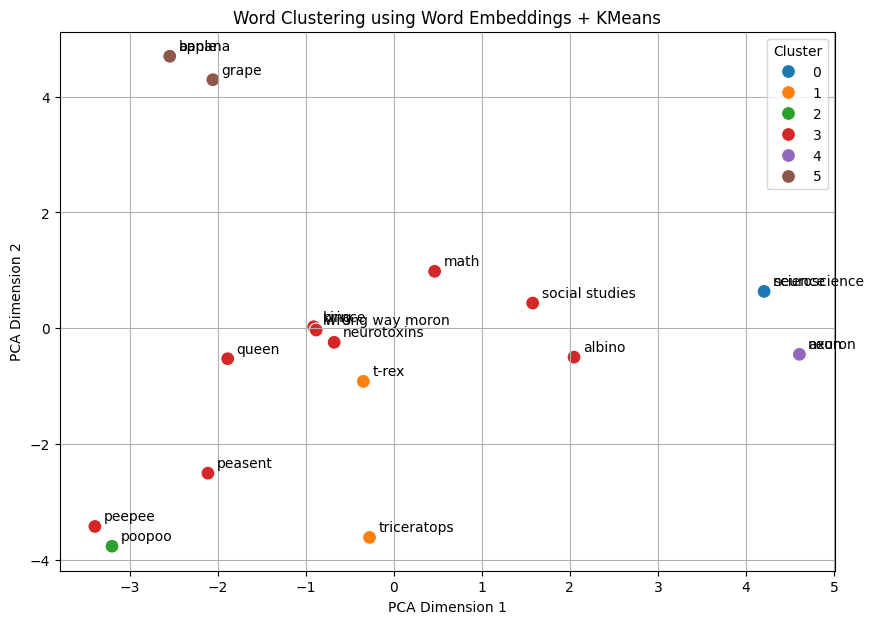

In [14]:
# 📦 Imports
import spacy
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import pandas as pd

# 🧠 Load spaCy's medium English model (includes word vectors)
nlp = spacy.load("en_core_web_md")

# ✍️ Input: List of words to cluster
words = ["apple", "banana", "grape", "king", "queen", "prince", "poopoo", "peepee", "t-rex", "albino", "neuroscience", "triceratops","peasent", "science", "axon", "neuron", "social studies", "math", "neurotoxins","wrong way moron"]

# 🔢 Extract word vectors
word_vectors = [nlp(word).vector for word in words]

# ⚙️ Clustering using KMeans
k = 6  # Number of clusters — adjust as needed
kmeans = KMeans(n_clusters=k, random_state=0, n_init="auto")
labels = kmeans.fit_predict(word_vectors)

# 🔍 Reduce dimensions for visualization (2D)
pca = PCA(n_components=2)
points_2d = pca.fit_transform(word_vectors)

# 🧾 Show cluster assignments as a table
df = pd.DataFrame({
    "Word": words,
    "Cluster": labels,
    "PCA_1": points_2d[:, 0],
    "PCA_2": points_2d[:, 1]
})
print("📊 Cluster Assignments:")
print(df)

# 🎨 Plot the clustered words
plt.figure(figsize=(10, 7))
sns.scatterplot(x=points_2d[:, 0], y=points_2d[:, 1], hue=labels, palette="tab10", s=100)

# Annotate each point with the word
for i, word in enumerate(words):
    plt.text(points_2d[i, 0]+0.1, points_2d[i, 1]+0.1, word)

plt.title("Word Clustering using Word Embeddings + KMeans")
plt.xlabel("PCA Dimension 1")
plt.ylabel("PCA Dimension 2")
plt.legend(title="Cluster")
plt.grid(True)
plt.show()



